# Advanced Sentiment Analysis Web Application
## Using RNN, LSTM, and GRU | IMDb 50K Movie Reviews Dataset

**Project Type:** End-to-End Deep Learning NLP Project (Binary Sentiment Classification)

---

### Objective
Build and compare three deep learning architectures — **Simple RNN**, **LSTM**, and **GRU** —
to classify IMDb movie reviews as **Positive** or **Negative**. This notebook covers dataset
exploration, preprocessing, vectorization, model building, training, evaluation, and
comparison. The final trained artifacts (best model, tokenizer, label encoder, configs)
will later be served through a FastAPI backend with a web frontend.

### Notebook Structure
1. Import Libraries
2. Load Dataset
3. Dataset Exploration
4. Exploratory Data Analysis (EDA)
5. Text Preprocessing
6. Text Vectorization
7. Train/Validation/Test Split
8. Model Building (RNN, LSTM, GRU)
9. Model Training
10. Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
11. Comparison Graphs & Table
12. Save Artifacts (Best Model, Tokenizer, Label Encoder, Config)

### Dataset
- **Source:** IMDb 50K Movie Reviews Dataset (Kaggle)
- **Columns:** `review` (text), `sentiment` (positive/negative)
- **Expected path:** `../dataset/IMDB_Dataset.csv`

## Part 2 — Import Libraries

In [1]:
# Core
import os
import re
import time
import string
import json
import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

# Download required NLTK resources (only runs once)
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.21.0
All libraries imported successfully.


## Project Setup — Create Working Folders

This cell creates all folders this notebook needs (`dataset`, `graphs`, `models`, `tokenizer`, `results`) right next to this notebook file, if they don't already exist. Run this once before anything else.

In [2]:
import os

for folder in ["dataset", "graphs", "models", "tokenizer", "results"]:
    os.makedirs(folder, exist_ok=True)

print("Working folders ready:", os.listdir("."))

Working folders ready: ['.anaconda', '.conda', '.continuum', '.copilot', '.git', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.streamlit', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Course', 'dataset', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'graphs', 'IMDB Dataset.csv', 'Links', 'Local Settings', 'models', 'model_artifacts', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{e6ec2097-2aa0-11f0-8a59-bae5ac36cfed}.TM.blf', 'NTUSER.DAT{e6ec2097-2aa0-11f0-8a59-bae5ac36cfed}.TM.blf.cnpf', 'NTUSER.DAT{e6ec2097-2aa0-11f0-8a59-bae5ac36cfed}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{e6ec2097-2aa0-11f0-8a59-bae5ac36cfed}.TMContainer00000000000000000001.regtrans-ms.cnpf', 'NTUSER.DAT{e6ec2097-2aa0-11f0-8a59-bae5ac36cfed}.TMContainer00000000000000000002.regtrans-ms', 'NTUSER.DAT{e6ec2097-2aa0-11f0-8a59-bae5ac

## Part 3 — Load Dataset

Place the IMDb 50K Reviews CSV at `../dataset/IMDB_Dataset.csv` (columns: `review`, `sentiment`).
Download link: Kaggle → "IMDB Dataset of 50K Movie Reviews".

In [3]:
import os
import pandas as pd

DATASET_PATH =(r"IMDB Dataset.csv")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset loaded successfully with shape: {df.shape}")
df.head()

Dataset loaded successfully with shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Part 4 — Dataset Exploration

In [4]:
# Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


In [5]:
# Columns
print("Columns:", list(df.columns))

Columns: ['review', 'sentiment']


In [6]:
# Data Types
df.dtypes

review       object
sentiment    object
dtype: object

In [7]:
# Missing Values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
review       0
sentiment    0
dtype: int64


In [8]:
# Duplicate Values
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 418
Shape after removing duplicates: (49582, 2)


In [9]:
# Class Distribution
print(df["sentiment"].value_counts())
print()
print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

sentiment
positive    50.187568
negative    49.812432
Name: proportion, dtype: float64


## Part 5 — Exploratory Data Analysis (EDA)

### 5.1 Class Distribution

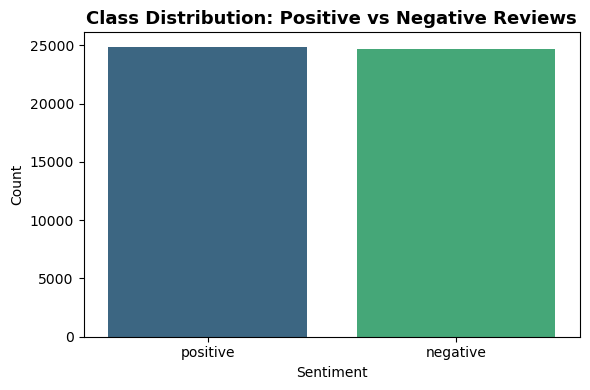

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x="sentiment", data=df, palette="viridis")
plt.title("Class Distribution: Positive vs Negative Reviews", fontsize=13, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("graphs/class_distribution.png", dpi=150)
plt.show()

### 5.2 Review Length Distribution

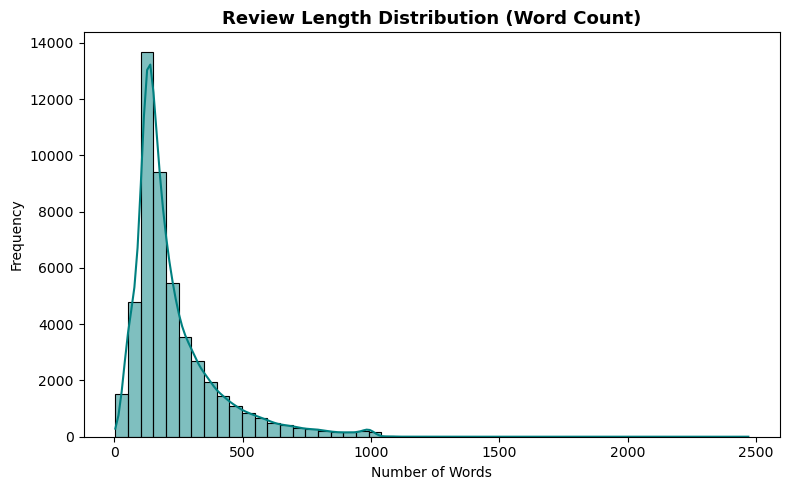

count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: review_length, dtype: float64


In [11]:
df["review_length"] = df["review"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
sns.histplot(df["review_length"], bins=50, kde=True, color="teal")
plt.title("Review Length Distribution (Word Count)", fontsize=13, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("graphs/review_length_histogram.png", dpi=150)
plt.show()

print(df["review_length"].describe())

### 5.3 Box Plot of Review Length

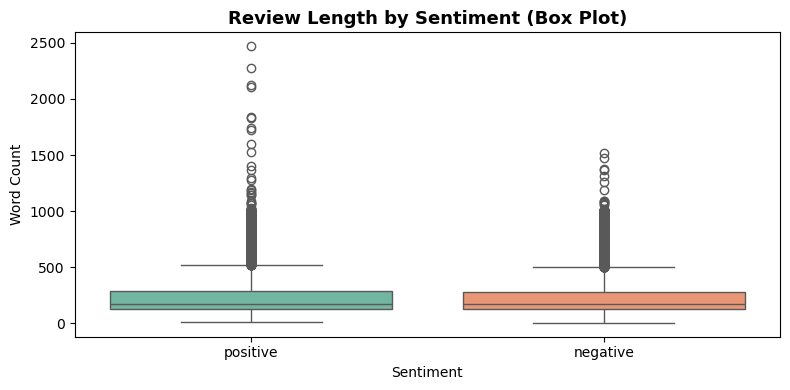

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="sentiment", y="review_length", data=df, palette="Set2")
plt.title("Review Length by Sentiment (Box Plot)", fontsize=13, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig("graphs/review_length_boxplot.png", dpi=150)
plt.show()

### 5.4 Most Frequent Words (Overall)

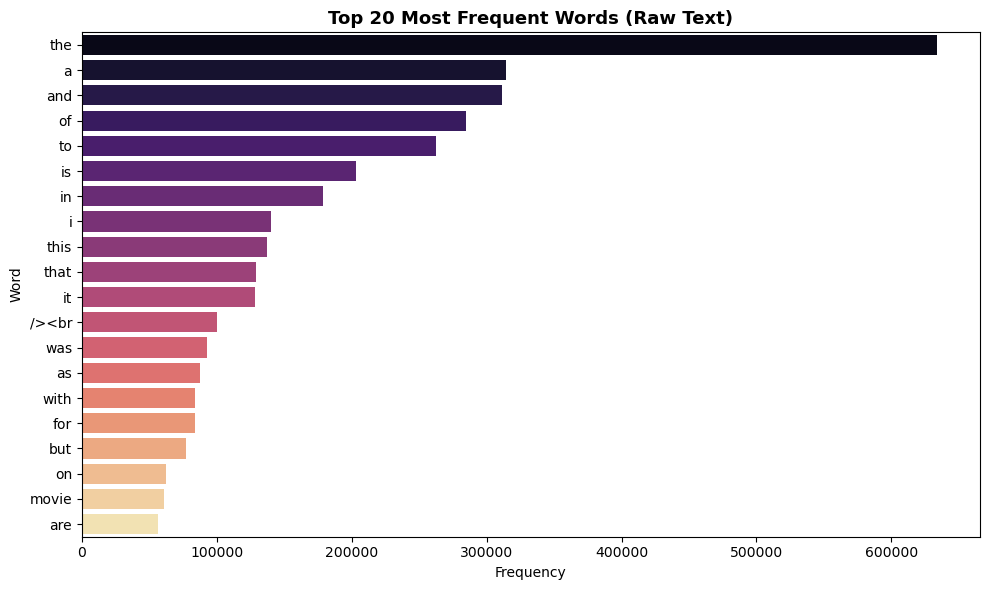

In [13]:
from collections import Counter

def get_word_freq(text_series, top_n=20):
    all_words = " ".join(text_series.astype(str)).lower().split()
    freq = Counter(all_words)
    return freq.most_common(top_n)

top_words = get_word_freq(df["review"], top_n=20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette="magma")
plt.title("Top 20 Most Frequent Words (Raw Text)", fontsize=13, fontweight="bold")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("graphs/word_frequency.png", dpi=150)
plt.show()

### 5.5 Positive Word Cloud

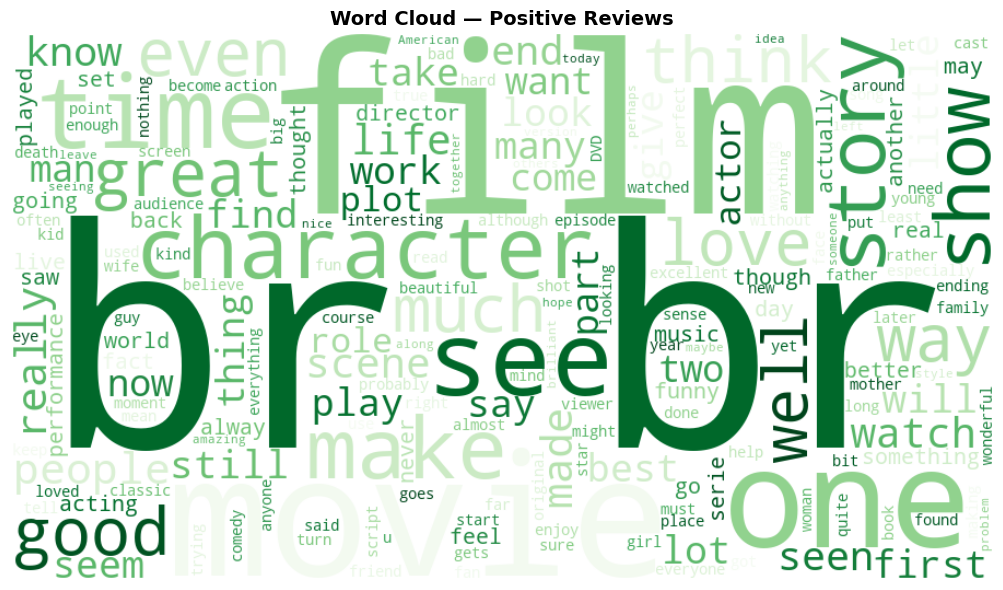

In [14]:
positive_text = " ".join(df[df["sentiment"] == "positive"]["review"].astype(str))

wc_pos = WordCloud(width=900, height=500, background_color="white",
                    colormap="Greens", max_words=200).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Positive Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graphs/positive_wordcloud.png", dpi=150)
plt.show()

### 5.6 Negative Word Cloud

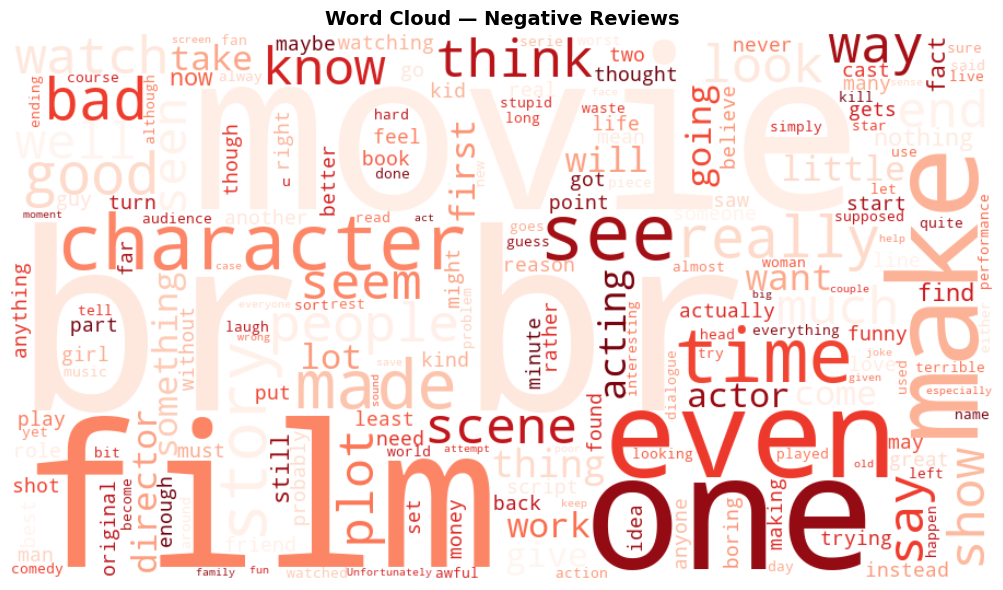

In [15]:
negative_text = " ".join(df[df["sentiment"] == "negative"]["review"].astype(str))

wc_neg = WordCloud(width=900, height=500, background_color="white",
                    colormap="Reds", max_words=200).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Negative Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("graphs/negative_wordcloud.png", dpi=150)
plt.show()

## Part 6 — Text Preprocessing

Steps: lowercase conversion, HTML tag removal, URL removal, punctuation removal,
number removal, extra-space removal, tokenization, stopword removal, and lemmatization.

In [16]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                                  # Lowercase
    text = re.sub(r"<.*?>", " ", text)                         # Remove HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)               # Remove URLs
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)  # Remove punctuation
    text = re.sub(r"\d+", " ", text)                           # Remove numbers
    text = re.sub(r"\s+", " ", text).strip()                   # Remove extra spaces

    tokens = word_tokenize(text)                               # Tokenization
    tokens = [w for w in tokens if w not in stop_words]        # Stopword removal
    tokens = [lemmatizer.lemmatize(w) for w in tokens]         # Lemmatization

    return " ".join(tokens)

print("Preprocessing function ready. Applying to dataset (this may take a few minutes)...")

Preprocessing function ready. Applying to dataset (this may take a few minutes)...


In [17]:
df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [18]:
# Encode target labels: positive -> 1, negative -> 0
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
df[["sentiment", "label"]].drop_duplicates()

Label mapping: {'negative': np.int64(0), 'positive': np.int64(1)}


,sentiment,label
0,positive,1
3,negative,0


## Part 7 — Text Vectorization

Build a vocabulary with Keras `Tokenizer`, convert cleaned text to integer sequences,
and pad sequences to a fixed length.

In [19]:
VOCAB_SIZE = 20000
MAX_LEN = 200
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df["clean_review"])

sequences = tokenizer.texts_to_sequences(df["clean_review"])
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

actual_vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

print(f"Vocabulary size (unique words found): {len(tokenizer.word_index)}")
print(f"Vocabulary size used by model: {actual_vocab_size}")
print(f"Padded sequences shape: {padded_sequences.shape}")

Vocabulary size (unique words found): 91019
Vocabulary size used by model: 20000
Padded sequences shape: (49582, 200)


## Part 8 — Train / Validation / Test Split

Split into 70% training, 15% validation, and 15% testing.

In [20]:
X = padded_sequences
y = df["label"].values

# First split: train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Second split: validation vs test (each 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")

Training samples:   34707
Validation samples: 7437
Testing samples:    7438


## Part 9 — Deep Learning Models

Three architectures will be built and compared: **Simple RNN**, **LSTM**, and **GRU**.
Each model uses: Embedding → Recurrent Layer → Dropout → Dense → Dropout → Sigmoid Output.

In [21]:
EMBEDDING_DIM = 128
RNN_UNITS = 64

def build_rnn_model(vocab_size, embedding_dim, max_len, rnn_units):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SimpleRNN(rnn_units, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ], name="Simple_RNN_Model")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_lstm_model(vocab_size, embedding_dim, max_len, rnn_units):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        LSTM(rnn_units, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ], name="LSTM_Model")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_gru_model(vocab_size, embedding_dim, max_len, rnn_units):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        GRU(rnn_units, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ], name="GRU_Model")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

print("Model-building functions defined for RNN, LSTM, and GRU.")

Model-building functions defined for RNN, LSTM, and GRU.


### 9.1 Model 1 — Simple RNN

In [22]:
rnn_model = build_rnn_model(actual_vocab_size, EMBEDDING_DIM, MAX_LEN, RNN_UNITS)
rnn_model.summary()

Model: "Simple_RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 9.2 Model 2 — LSTM

In [23]:
lstm_model = build_lstm_model(actual_vocab_size, EMBEDDING_DIM, MAX_LEN, RNN_UNITS)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 9.3 Model 3 — GRU

In [24]:
gru_model = build_gru_model(actual_vocab_size, EMBEDDING_DIM, MAX_LEN, RNN_UNITS)
gru_model.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Part 10 — Model Training

Each model is trained with early stopping (monitoring validation loss) to prevent overfitting.
Training time and epoch history are recorded for every model.

In [25]:
EPOCHS = 10
BATCH_SIZE = 128

early_stop = EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)

def train_model(model, X_train, y_train, X_val, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE):
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return history, training_time

training_times = {}
histories = {}

In [26]:
# Train Simple RNN
print("=" * 60)
print("Training Simple RNN Model")
print("=" * 60)
histories["RNN"], training_times["RNN"] = train_model(rnn_model, X_train, y_train, X_val, y_val)

Training Simple RNN Model
Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.5034 - loss: 0.6968 - val_accuracy: 0.5058 - val_loss: 0.6932
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 35s 129ms/step - accuracy: 0.5263 - loss: 0.6873 - val_accuracy: 0.5054 - val_loss: 0.6951
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 36s 132ms/step - accuracy: 0.5125 - loss: 0.7061 - val_accuracy: 0.4993 - val_loss: 0.6937

Training completed in 113.47 seconds.


In [28]:
# Train LSTM
print("=" * 60)
print("Training LSTM Model")
print("=" * 60)
histories["LSTM"], training_times["LSTM"] = train_model(lstm_model, X_train, y_train, X_val, y_val)

Training LSTM Model
Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 124s 427ms/step - accuracy: 0.5036 - loss: 0.6943 - val_accuracy: 0.5159 - val_loss: 0.6930
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 99s 363ms/step - accuracy: 0.5189 - loss: 0.6883 - val_accuracy: 0.5306 - val_loss: 0.6810
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 96s 352ms/step - accuracy: 0.5492 - loss: 0.6530 - val_accuracy: 0.5366 - val_loss: 0.6892
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 98s 360ms/step - accuracy: 0.5806 - loss: 0.6155 - val_accuracy: 0.8103 - val_loss: 0.5544
Epoch 5/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 99s 363ms/step - accuracy: 0.8624 - loss: 0.3495 - val_accuracy: 0.8614 - val_loss: 0.3654
Epoch 6/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 100s 367ms/step - accuracy: 0.9306 - loss: 0.2088 - val_accuracy: 0.8670 - val_loss: 0.3833
Epoch 7/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 99s 365ms/step - accuracy: 0.9511 - loss: 0.1547 - val_accuracy: 0.8649 - val_loss: 0.5011

Training completed in 714.86 seconds.


In [29]:
# Train GRU
print("=" * 60)
print("Training GRU Model")
print("=" * 60)
histories["GRU"], training_times["GRU"] = train_model(gru_model, X_train, y_train, X_val, y_val)

Training GRU Model
Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 107s 365ms/step - accuracy: 0.5044 - loss: 0.6935 - val_accuracy: 0.5097 - val_loss: 0.6925
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 95s 348ms/step - accuracy: 0.5222 - loss: 0.6863 - val_accuracy: 0.5174 - val_loss: 0.6919
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 95s 349ms/step - accuracy: 0.6157 - loss: 0.6137 - val_accuracy: 0.8085 - val_loss: 0.4431
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 95s 349ms/step - accuracy: 0.8844 - loss: 0.3038 - val_accuracy: 0.8736 - val_loss: 0.3244
Epoch 5/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 94s 344ms/step - accuracy: 0.9400 - loss: 0.1774 - val_accuracy: 0.8745 - val_loss: 0.3963
Epoch 6/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 96s 353ms/step - accuracy: 0.9650 - loss: 0.1123 - val_accuracy: 0.8706 - val_loss: 0.4175

Training completed in 581.95 seconds.


In [30]:
# Save all trained models
os.makedirs("models", exist_ok=True)

rnn_model.save("models/rnn.keras")
lstm_model.save("models/lstm.keras")
gru_model.save("models/gru.keras")

print("All models saved to models/")

All models saved to models/


## Part 11 — Training Graphs (Accuracy & Loss vs Epoch)

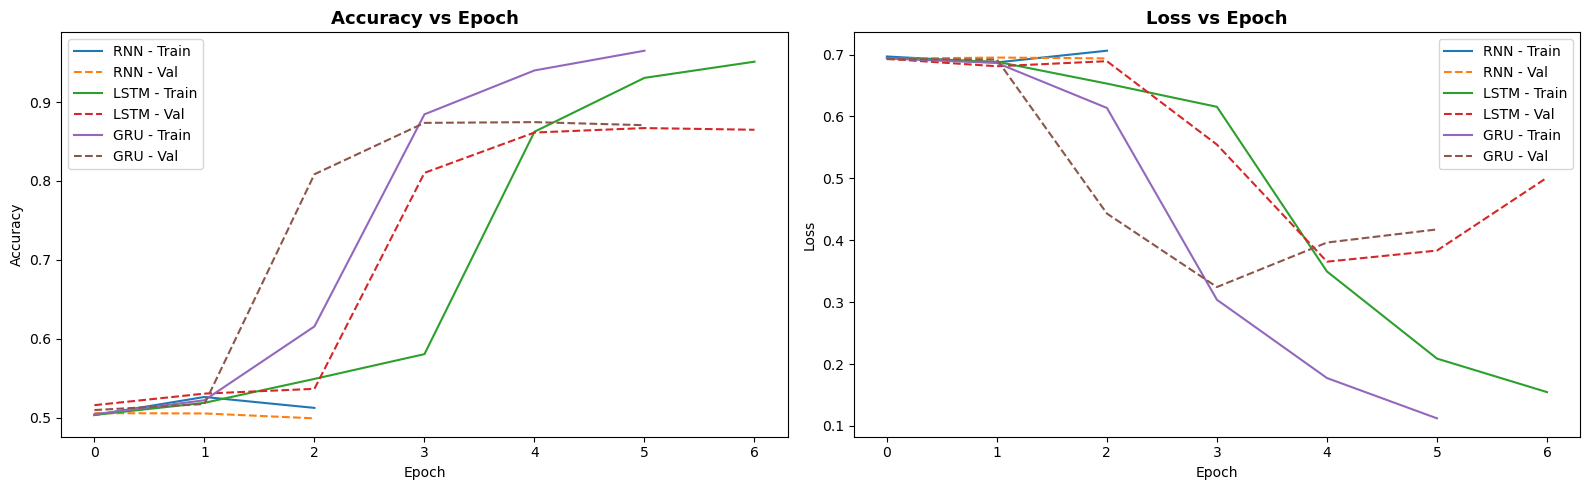

In [31]:
def plot_training_history(histories_dict):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for name, history in histories_dict.items():
        axes[0].plot(history.history["accuracy"], label=f"{name} - Train")
        axes[0].plot(history.history["val_accuracy"], linestyle="--", label=f"{name} - Val")

    axes[0].set_title("Accuracy vs Epoch", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    for name, history in histories_dict.items():
        axes[1].plot(history.history["loss"], label=f"{name} - Train")
        axes[1].plot(history.history["val_loss"], linestyle="--", label=f"{name} - Val")

    axes[1].set_title("Loss vs Epoch", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("graphs/training_curves.png", dpi=150)
    plt.show()

plot_training_history(histories)

## Part 12 — Model Evaluation

Evaluate every model on the held-out test set using Accuracy, Precision, Recall, F1 Score,
ROC-AUC, Confusion Matrix, and full Classification Report.

In [32]:
models_dict = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

results = []
predictions_store = {}

for name, model in models_dict.items():
    start_pred = time.time()
    y_prob = model.predict(X_test, verbose=0).flatten()
    pred_time = time.time() - start_pred

    y_pred = (y_prob >= 0.5).astype(int)
    predictions_store[name] = {"y_prob": y_prob, "y_pred": y_pred}

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Training Time (s)": training_times[name],
        "Prediction Time (s)": pred_time
    })

    print(f"\n{'='*60}\n{name} Model — Classification Report\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

results_df = pd.DataFrame(results)
results_df


RNN Model — Classification Report
              precision    recall  f1-score   support

    negative       0.50      0.88      0.64      3705
    positive       0.52      0.13      0.21      3733

    accuracy                           0.50      7438
   macro avg       0.51      0.51      0.42      7438
weighted avg       0.51      0.50      0.42      7438


LSTM Model — Classification Report
              precision    recall  f1-score   support

    negative       0.92      0.79      0.85      3705
    positive       0.82      0.93      0.87      3733

    accuracy                           0.86      7438
   macro avg       0.87      0.86      0.86      7438
weighted avg       0.87      0.86      0.86      7438


GRU Model — Classification Report
              precision    recall  f1-score   support

    negative       0.91      0.84      0.88      3705
    positive       0.85      0.92      0.89      3733

    accuracy                           0.88      7438
   macro avg       0.8

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s),Prediction Time (s)
0,RNN,0.503630,0.522453,0.127779,0.205338,0.499089,113.466401,11.124400
1,LSTM,0.861119,0.816011,0.933833,0.870956,0.936847,714.856772,12.367068
2,GRU,0.881420,0.854161,0.920975,0.886311,0.945139,581.949302,11.908372


### 12.1 Confusion Matrices

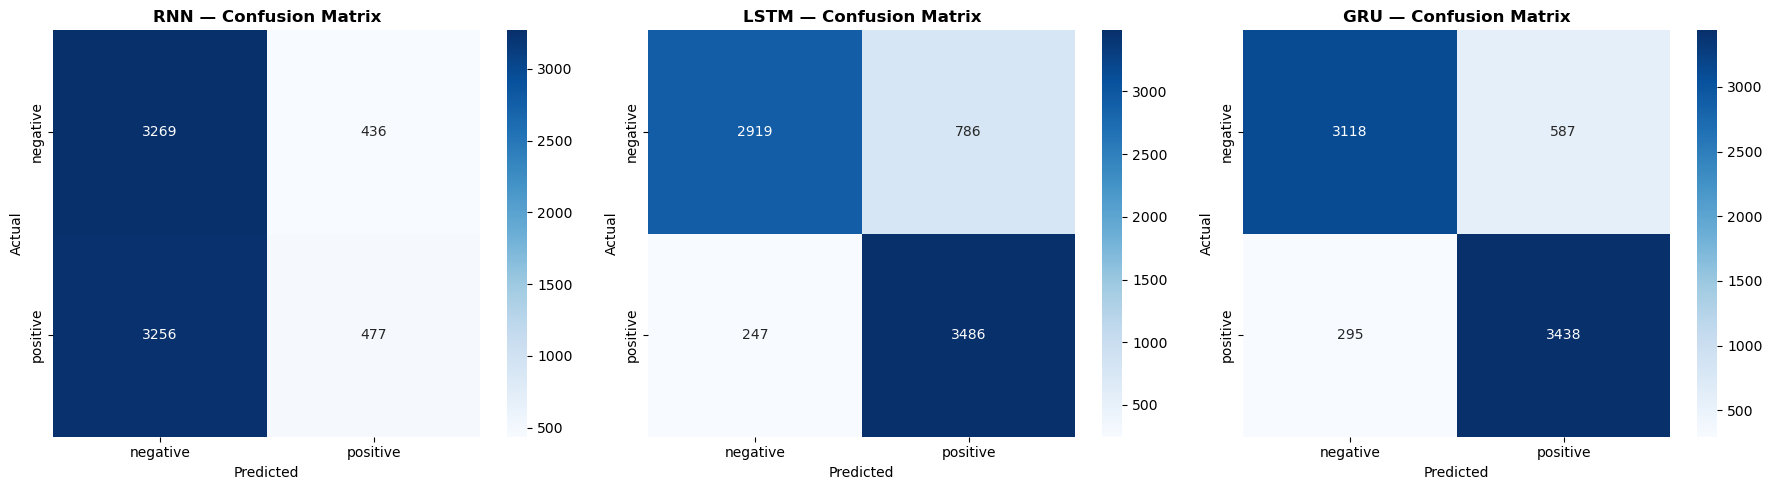

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, predictions_store.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("graphs/confusion_matrices.png", dpi=150)
plt.show()

### 12.2 ROC Curves

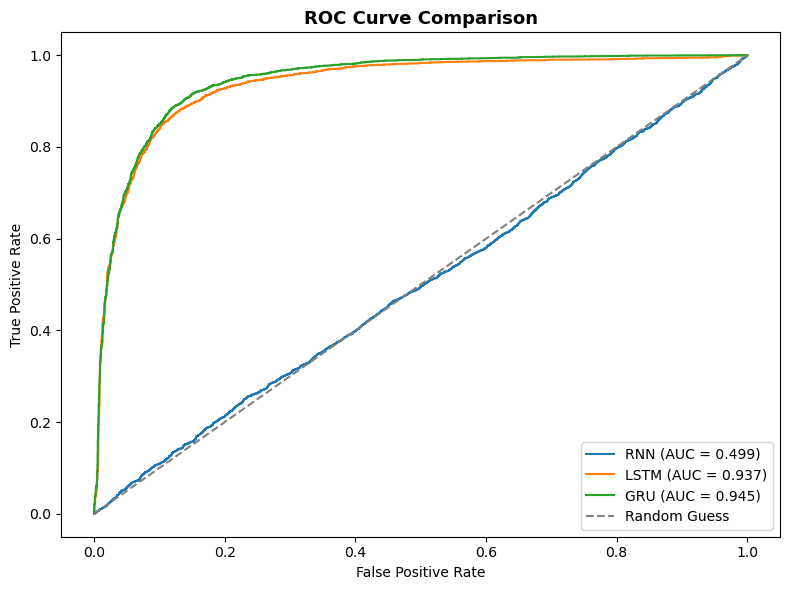

In [34]:
plt.figure(figsize=(8, 6))

for name, preds in predictions_store.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    auc_score = roc_auc_score(y_test, preds["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve Comparison", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("graphs/roc_curves.png", dpi=150)
plt.show()

### 12.3 Precision-Recall Curves

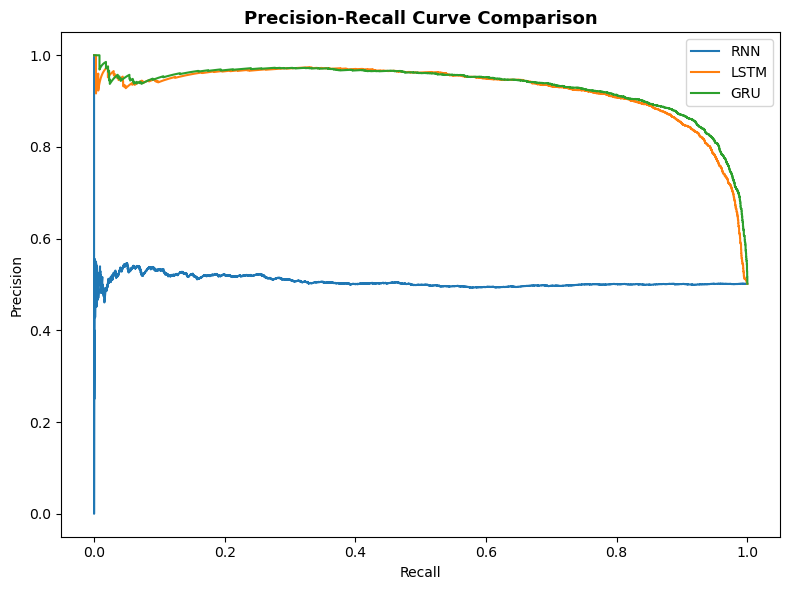

In [35]:
plt.figure(figsize=(8, 6))

for name, preds in predictions_store.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, preds["y_prob"])
    plt.plot(recall_vals, precision_vals, label=name)

plt.title("Precision-Recall Curve Comparison", fontsize=13, fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("graphs/precision_recall_curves.png", dpi=150)
plt.show()

## Part 13 — Model Comparison Graphs

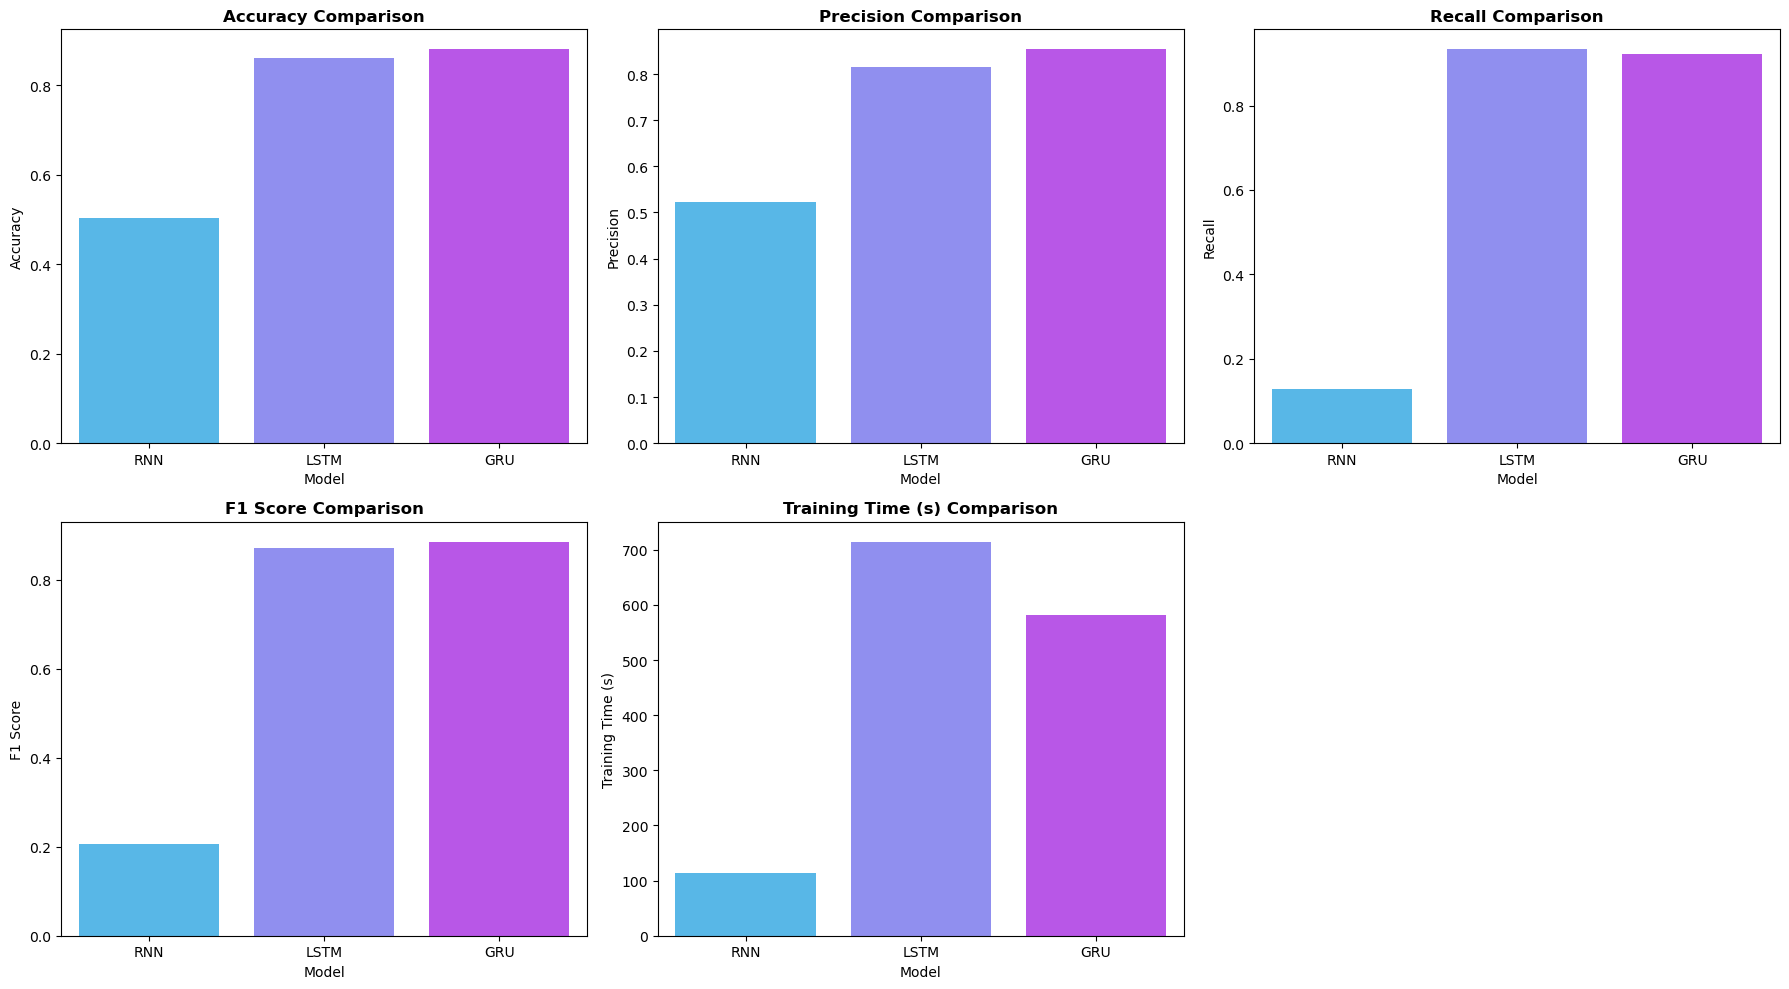

In [36]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x="Model", y=metric, data=results_df, ax=axes[i], palette="cool")
    axes[i].set_title(f"{metric} Comparison", fontweight="bold")
    axes[i].set_ylabel(metric)

# Hide the unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("graphs/model_comparison.png", dpi=150)
plt.show()

## Part 14 — Final Comparison Table & Best Model Selection

In [37]:
comparison_table = results_df.copy()
comparison_table = comparison_table.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("Final Model Comparison Table:")
display(comparison_table)

best_model_name = comparison_table.iloc[0]["Model"]
best_model = models_dict[best_model_name]

print(f"\nBest performing model based on F1 Score: {best_model_name}")

# Save comparison table
os.makedirs("results", exist_ok=True)
comparison_table.to_csv("results/model_comparison.csv", index=False)
print("Comparison table saved to results/model_comparison.csv")

Final Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s),Prediction Time (s)
0,GRU,0.881420,0.854161,0.920975,0.886311,0.945139,581.949302,11.908372
1,LSTM,0.861119,0.816011,0.933833,0.870956,0.936847,714.856772,12.367068
2,RNN,0.503630,0.522453,0.127779,0.205338,0.499089,113.466401,11.124400



Best performing model based on F1 Score: GRU
Comparison table saved to results/model_comparison.csv


## Part 15 — Save Final Artifacts

Save the best model, tokenizer, label encoder, and configuration file for use in the
FastAPI backend.

In [38]:
import pickle

os.makedirs("models", exist_ok=True)
os.makedirs("tokenizer", exist_ok=True)

# Save best model separately for easy backend loading
best_model.save("models/best_model.keras")

# Save tokenizer
with open("tokenizer/tokenizer.pickle", "wb") as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

# Save label encoder
with open("tokenizer/label_encoder.pickle", "wb") as f:
    pickle.dump(label_encoder, f, protocol=pickle.HIGHEST_PROTOCOL)

# Save configuration file
config = {
    "vocab_size": actual_vocab_size,
    "max_len": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "rnn_units": RNN_UNITS,
    "best_model_name": best_model_name,
    "best_model_path": "models/best_model.keras",
    "available_models": {
        "RNN": "models/rnn.keras",
        "LSTM": "models/lstm.keras",
        "GRU": "models/gru.keras"
    },
    "label_mapping": {str(cls): int(idx) for idx, cls in enumerate(label_encoder.classes_)},
    "dataset_size": int(df.shape[0]),
    "training_samples": int(X_train.shape[0]),
    "validation_samples": int(X_val.shape[0]),
    "testing_samples": int(X_test.shape[0])
}

with open("tokenizer/config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Artifacts saved successfully:")
print(" - models/best_model.keras")
print(" - tokenizer/tokenizer.pickle")
print(" - tokenizer/label_encoder.pickle")
print(" - tokenizer/config.json")

Artifacts saved successfully:
 - models/best_model.keras
 - tokenizer/tokenizer.pickle
 - tokenizer/label_encoder.pickle
 - tokenizer/config.json


---
## Summary

This notebook completed the full deep learning pipeline for IMDb sentiment analysis:

- Loaded and explored the 50K review dataset
- Performed EDA (class balance, review length, word clouds, frequency analysis)
- Cleaned and preprocessed text (HTML/URL/punctuation removal, tokenization, lemmatization)
- Vectorized text using Keras Tokenizer with padding
- Built, trained, and evaluated **RNN**, **LSTM**, and **GRU** models
- Compared all models on Accuracy, Precision, Recall, F1, ROC-AUC, and speed
- Saved the best model, tokenizer, label encoder, and config for backend deployment

**Next step:** Build the FastAPI backend (`/predict`, `/predict-batch`, `/model-info`, etc.)
and the responsive frontend, connecting them via REST APIs.